In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rd

In [2]:
drive = pd.read_csv('dataset.csv').sample(400000)
drive.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 400000 entries, 771062 to 400317
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   DriverId    400000 non-null  int64  
 1   EventName   400000 non-null  object 
 2   Latitude    400000 non-null  float64
 3   Longitude   400000 non-null  float64
 4   Speed km/h  400000 non-null  float64
 5   ts          400000 non-null  object 
dtypes: float64(3), int64(1), object(2)
memory usage: 21.4+ MB


In [3]:
drive.describe()

,DriverId,Latitude,Longitude,Speed km/h
count,400000.00000,400000.000000,400000.000000,400000.000000
mean,43.59933,34.150536,-118.170015,63.131065
std,26.44110,0.449127,0.164722,39.032883
min,0.00000,31.552999,-118.661771,0.000000
25%,19.00000,33.941123,-118.284576,30.000000
50%,45.00000,34.105484,-118.209498,65.000000
75%,65.00000,34.429527,-118.085851,96.000000
max,88.00000,35.248460,-117.440547,180.000000


In [4]:
drive = drive.drop_duplicates()
drive = drive.drop(drive[drive['Speed km/h'] < 5].index)

In [5]:
drive.sample(10)

,DriverId,EventName,Latitude,Longitude,Speed km/h,ts
720884,73,Distance Event,34.522313,-117.682201,95.0,2017-11-10 07:31:49.510
622977,59,Timed Event,34.961709,-117.922416,23.0,2017-11-16 16:36:18.490
823031,82,Distance Event,34.083352,-118.250598,73.0,2017-11-08 15:19:54.760
105451,8,Distance Event,34.032682,-118.274158,134.0,2017-11-05 14:55:04.580
90764,7,Distance Event,32.699601,-118.300531,109.0,2017-11-02 15:34:12.320
751292,76,Distance Event,34.068105,-118.187849,92.0,2017-11-07 10:57:00.030
474855,47,Distance Event,34.767497,-117.863945,93.0,2017-11-09 12:05:27.310
620245,59,Timed Event,34.941975,-117.932344,8.0,2017-11-12 16:20:29.410
490400,48,Distance Event,33.970277,-118.291515,65.0,2017-11-01 19:45:35.170
405507,42,Distance Event,34.127229,-118.121653,34.0,2017-11-12 18:23:42.380


In [6]:
drive.EventName.value_counts()

Distance Event                       300074
Timed Event                           37790
Harsh Acceleration                     7193
System Event                           2595
Harsh Braking                          2544
Reached max speed                      2427
Network Event                          1108
Out of max speed                       1083
Harsh Turn (motion based)              1025
Harsh Braking (motion based)            613
Engine started                          545
Engine turned off                       417
Harsh Acceleration (motion based)       362
Harsh Turn Left (motion based)          362
Harsh Turn Right (motion based)         361
Name: EventName, dtype: int64

In [7]:
drp = ['System Event', 'Network Event','Engine turned off', 'Engine started','Distance Event']
rest = list(set(drive.EventName.unique()).difference(set(drp)))
make = drive[drive.EventName.isin(rest)]

In [8]:
make = make.replace({'EventName': {'Harsh Acceleration (motion based)':'Harsh Acceleration',
                       'Harsh Braking (motion based)':'Harsh Braking',
                        'Harsh Acceleration (motion based)':'Harsh Acceleration',
                        'Harsh Turn Left (motion based)':'Harsh Turn',
                        'Harsh Turn Right (motion based)':'Harsh Turn',
                        'Harsh Turn (motion based)':'Harsh Turn',
                        'Reached max speed': 'Beyond max speed',
                        'Out of max speed':'Beyond max speed'}})

make.EventName.value_counts()

Timed Event           37790
Harsh Acceleration     7555
Beyond max speed       3510
Harsh Braking          3157
Harsh Turn             1748
Name: EventName, dtype: int64

In [9]:
make.columns, make.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 53760 entries, 861533 to 72677
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DriverId    53760 non-null  int64  
 1   EventName   53760 non-null  object 
 2   Latitude    53760 non-null  float64
 3   Longitude   53760 non-null  float64
 4   Speed km/h  53760 non-null  float64
 5   ts          53760 non-null  object 
dtypes: float64(3), int64(1), object(2)
memory usage: 2.9+ MB


(Index(['DriverId', 'EventName', 'Latitude', 'Longitude', 'Speed km/h', 'ts'], dtype='object'),
 None)

In [10]:
# Days of the Week
import datetime
make.ts = pd.to_datetime(make.ts) #.strftime('%d/%m/%Y %H:%M')
make['Days'] =  [t.date().strftime('%A') for t in make.ts]
# dty = ['Saturday', 'Sunday']
# make['Week'] = ['Weekend' if i in dty else 'Weekday' for i in make.Days]

# Visibility
make['visiblity'] = [ 0 if i.time().hour in range(6, 21) else 1 for i in make.ts]

# Aggressive Driving
crz = ['Harsh Acceleration', 'Harsh Braking', 'Harsh Turn', 'Beyond max speed']
make['agg_drv'] = [1 if i in crz else 0 for i in make.EventName]

# Overspeed
# Speed threshold is set at 80 km/h and excess at 100
make['overspeed'] = [1 if make.iloc[i]['Speed km/h'] > 80 else 1 if make.iloc[i]['EventName']=='Harsh Turn' 
                        and make.iloc[i]['Speed km/h'] > 40 else 0 for i in range(len(make))]
make['lmt_dev'] = [round((make.iloc[i]['Speed km/h'] - 80)/80, 2) for i in range(len(make))]

# Fatigue Driving
# Fatigue driving is aroung afternoon towards the evening. 1 in 25 drivers suffer this
make['fatigue'] = [rd.choices([1, 0], weights=[1,25], k=1)[0] if i.time().hour in range(12,24) else 0 for i in make.ts] # Self generated

# Possible collision distance
# This is a subraction of stopping distance from car distance:
# Taking reaction time to be 0.75s for normal and 1.5 for fatigued, road coef to asphalt 0.8,
# car distance to 3s
make['col_dist'] = [round((make.iloc[i]['Speed km/h'] *3)/3.6 - ((make.iloc[i]['Speed km/h'] * 1.5)/3.6 + make.iloc[i]['Speed km/h']**2/(250*0.8)), 2)  
                    if make.iloc[i]['fatigue']== 1 else round((make.iloc[i]['Speed km/h']*3)/3.6 - ((make.iloc[i]['Speed km/h'] * 0.75)/3.6 + make.iloc[i]['Speed km/h']**2/(250*0.8)), 2) 
                    for i in range(len(make))]

make['col_distd'] = [1 if i < 0 else 0 for i in make.col_dist]



In [11]:
# Based on research, respective weight for each driver behaviour was acquired
make['Fault'] = [round((0.051*make.iloc[i]['visiblity'] + 0.07326*make.iloc[i]['agg_drv']
                    + 0.225 * make.iloc[i]['fatigue'] +  0.0267*make.iloc[i]['overspeed'] + 0.0411*make.iloc[i]['col_distd']) * 10,2)
                    for i in range(len(make))]
make['Decision'] = [1 if round(1 - 1 / (1 + i), 2) > 0.49 else 0 for i in make.Fault]

In [12]:
make.head(10)

,DriverId,EventName,Latitude,Longitude,Speed km/h,ts,Days,visiblity,agg_drv,overspeed,lmt_dev,fatigue,col_dist,col_distd,Fault,Decision
861533,86,Timed Event,34.313679,-118.224368,23.0,2017-11-16 16:57:01.430,Thursday,0,0,0,-0.71,0,11.73,0,0.00,0
625794,60,Timed Event,34.137663,-118.291034,7.0,2017-11-06 08:10:05.410,Monday,0,0,0,-0.91,0,4.13,0,0.00,0
400326,41,Timed Event,34.444106,-118.153207,18.0,2017-11-16 16:49:27.050,Thursday,0,0,0,-0.78,0,9.63,0,0.00,0
207116,18,Timed Event,34.088129,-118.299211,10.0,2017-11-02 06:34:08.860,Thursday,0,0,0,-0.88,0,5.75,0,0.00,0
884815,88,Timed Event,34.933076,-117.847237,66.0,2017-11-03 12:24:12.000,Friday,0,0,0,-0.18,0,19.47,0,0.00,0
700230,69,Timed Event,34.781399,-118.093679,16.0,2017-11-15 14:37:54.890,Wednesday,0,0,0,-0.80,0,8.72,0,0.00,0
841569,85,Timed Event,33.891970,-118.266050,78.0,2017-11-01 22:49:06.610,Wednesday,1,0,0,-0.02,0,18.33,0,0.51,0
316499,31,Harsh Acceleration,34.806840,-118.092007,50.0,2017-11-11 19:14:14.860,Saturday,0,1,0,-0.38,0,18.75,0,0.73,0
9197,0,Harsh Acceleration,34.194966,-118.147716,53.0,2017-11-10 14:42:27.750,Friday,0,1,0,-0.34,0,19.08,0,0.73,0
434760,45,Harsh Acceleration,33.870682,-118.219981,73.0,2017-11-06 09:23:55.910,Monday,0,1,0,-0.09,0,18.98,0,0.73,0


In [13]:
make = make.drop(['DriverId', 'Longitude', 'Latitude', 'ts'], axis=1)
make.corr() 

,Speed km/h,visiblity,agg_drv,overspeed,lmt_dev,fatigue,col_dist,col_distd,Fault,Decision
Speed km/h,1.000000,0.026604,0.198035,0.806267,0.999973,-0.004487,-0.063632,0.333809,0.340977,0.343870
visiblity,0.026604,1.000000,0.015319,0.013278,0.026577,0.008979,0.025188,0.007246,0.299742,0.206973
agg_drv,0.198035,0.015319,1.000000,0.068319,0.198081,-0.003072,0.168167,0.036494,0.637765,0.489353
overspeed,0.806267,0.013278,0.068319,1.000000,0.806065,-0.004348,-0.321881,0.272889,0.292277,0.402162
lmt_dev,0.999973,0.026577,0.198081,0.806065,1.000000,-0.004453,-0.063413,0.333657,0.340957,0.343757
fatigue,-0.004487,0.008979,-0.003072,-0.004348,-0.004453,1.000000,-0.276515,0.191141,0.660236,0.399228
col_dist,-0.063632,0.025188,0.168167,-0.321881,-0.063413,-0.276515,1.000000,-0.496448,-0.193999,-0.240362
col_distd,0.333809,0.007246,0.036494,0.272889,0.333657,0.191141,-0.496448,1.000000,0.323354,0.210546
Fault,0.340977,0.299742,0.637765,0.292277,0.340957,0.660236,-0.193999,0.323354,1.000000,0.726530
Decision,0.343870,0.206973,0.489353,0.402162,0.343757,0.399228,-0.240362,0.210546,0.726530,1.000000


In [14]:
# from matplotlib.pylab import rcParams
# rcParams['figure.figsize'] = 20,10

In [15]:
make.fatigue.value_counts()

0    52462
1     1298
Name: fatigue, dtype: int64

In [16]:
make.col_distd.value_counts()

0    52431
1     1329
Name: col_distd, dtype: int64

In [17]:
make.Decision.value_counts()

0    46536
1     7224
Name: Decision, dtype: int64

In [18]:
# sns.countplot(x= 'overspeed', data = make, hue ='visiblity')
# sns.jointplot(x = "overspeed", y = "Speed km/h", data= make, kind='reg')

In [19]:
# sns.jointplot(y= "col_dist", x = "Speed km/h", data= make, alpha =0.5)
# sns.barplot(x = 'Days', y='Speed km/h', data =make)
# sns.pairplot(make, hue='visiblity')

In [20]:
# sns.jointplot(x = "col_dist", y = "overspeed", data= make, kind='reg')
# sns.countplot(data = make, x='EventName')

In [21]:
make.EventName.value_counts()

Timed Event           37790
Harsh Acceleration     7555
Beyond max speed       3510
Harsh Braking          3157
Harsh Turn             1748
Name: EventName, dtype: int64

In [22]:
make.sample(20)

,EventName,Speed km/h,Days,visiblity,agg_drv,overspeed,lmt_dev,fatigue,col_dist,col_distd,Fault,Decision
861207,Timed Event,61.0,Wednesday,0,0,0,-0.24,0,19.52,0,0.00,0
761380,Timed Event,109.0,Friday,0,0,1,0.36,0,8.72,0,0.27,0
293797,Timed Event,114.0,Thursday,0,0,1,0.42,0,6.27,0,0.27,0
791042,Harsh Turn,44.0,Friday,0,1,1,-0.45,0,17.82,0,1.00,1
129908,Timed Event,69.0,Saturday,0,0,0,-0.14,0,19.32,0,0.00,0
703842,Harsh Acceleration,68.0,Thursday,0,1,0,-0.15,0,19.38,0,0.73,0
106036,Harsh Acceleration,75.0,Monday,0,1,0,-0.06,0,18.75,0,0.73,0
713795,Harsh Braking,39.0,Sunday,0,1,0,-0.51,0,16.77,0,0.73,0
389253,Timed Event,75.0,Saturday,0,0,0,-0.06,0,18.75,0,0.00,0
378248,Beyond max speed,92.0,Monday,1,1,1,0.15,0,15.18,0,1.51,1


In [23]:
make.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 53760 entries, 861533 to 72677
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EventName   53760 non-null  object 
 1   Speed km/h  53760 non-null  float64
 2   Days        53760 non-null  object 
 3   visiblity   53760 non-null  int64  
 4   agg_drv     53760 non-null  int64  
 5   overspeed   53760 non-null  int64  
 6   lmt_dev     53760 non-null  float64
 7   fatigue     53760 non-null  int64  
 8   col_dist    53760 non-null  float64
 9   col_distd   53760 non-null  int64  
 10  Fault       53760 non-null  float64
 11  Decision    53760 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 5.3+ MB


In [24]:
# Importing packages
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost.sklearn import XGBClassifier 

In [25]:
make.skew()

Speed km/h    0.500037
visiblity     2.693873
agg_drv       0.888231
overspeed     1.130636
lmt_dev       0.499269
fatigue       6.200359
col_dist     -1.330709
col_distd     6.122002
Fault         2.209507
Decision      2.144144
dtype: float64

In [26]:
# sk = [i for i in make.columns if abs(make[i].skew()) > 1]
# for i in sk:
#     make[i] = make[i].apply(lambda i: np.log(i) if i > 0 else 0)

# make.nunique()

In [45]:
maked = make.drop(['overspeed', 'agg_drv', 'col_distd', 'Fault', 'fatigue'], axis=1)

In [46]:
# stroke = stroke.drop('id' , axis =1)
train,test = train_test_split(maked, test_size = 0.2, random_state = 101)
X = train.drop(['Decision'], axis=1)
y = train.Decision

In [47]:
trainX,testX, trainy,testy= train_test_split(X, y, test_size = 0.2, random_state = 101)

In [48]:
import category_encoders as ce
encode = ce.TargetEncoder(cols= ['Days','EventName'])
trainX = encode.fit_transform(trainX, trainy)
testX = encode.transform(testX)

from imblearn.over_sampling import SMOTE
sm = SMOTE()
trainX, trainy = sm.fit_resample(trainX, trainy)

sc = StandardScaler()
trainX = sc.fit_transform(trainX)
testX = sc.transform(testX)

In [49]:
# Finding the BaseLine perfomance of the various models

# prepare models
models = []

# Adding algorthms
models.append(('sgd', SGDClassifier()))
models.append(('LR', LogisticRegression()))
# models.append(('knr', KNeighborsClassifier()))
models.append(('rfr', RandomForestClassifier()))
models.append(('xg', XGBClassifier(objective ='reg:squarederror')))
# evaluate -cross validation- each model in turn
results = []
names = []
scoring =['accuracy', 'f1']
for name, model in models:
	kfold = KFold(n_splits=10)
	cv_results = cross_validate(model, trainX, trainy, cv=kfold, scoring=scoring, return_train_score=True)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, cv_results['train_accuracy'].mean(), cv_results['test_f1'].mean())
	print(msg)


sgd: 0.873762 (0.788443)
LR: 0.874482 (0.789514)
rfr: 1.000000 (1.000000)
xg: 1.000000 (0.999785)


In [50]:
lr= LogisticRegression()
scores = cross_val_score(lr, trainX, trainy, cv=10, scoring = 'roc_auc') # Cross validation with scoring of ROC AUC
print(f'Validation score: {np.mean(scores)}')
ylr = lr.fit(trainX, trainy).predict(testX) # Prediction
ylrpb = lr.fit(trainX, trainy).predict_proba(testX)[:,1] # Probability of prediction
print(f'Train score:{lr.score(trainX, trainy)}')
print(f'Test score:{lr.score(testX, testy)}')

Validation score: 0.9460542970774565
Train score:0.8722795151677493
Test score:0.9042083236456638


In [51]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
print(classification_report(ylr, testy))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7001
           1       0.83      0.61      0.70      1601

    accuracy                           0.90      8602
   macro avg       0.87      0.79      0.82      8602
weighted avg       0.90      0.90      0.90      8602



In [52]:
Logist = pd.DataFrame({'True':testy, "Predicted":ylr, 'Probability':ylrpb})

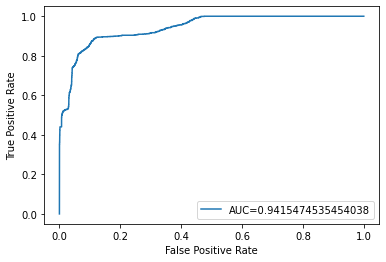

In [53]:
fpr, tpr, _ = roc_curve(testy,  ylrpb)
auc = roc_auc_score(testy, ylrpb)

plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()